<a href="https://colab.research.google.com/github/Madhankumar-17/Day-10/blob/main/Pkl_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression for TrafficIQ — Smart Traffic & Congestion Predictor

This section will demonstrate how to build a logistic regression model to classify spam messages using the 'smart_traffic_management_dataset.csv' dataset.

Saving smart_traffic_management_dataset.csv to smart_traffic_management_dataset.csv
          timestamp  location_id  traffic_volume  avg_vehicle_speed  \
0  01-01-2024 00:00            4             504          53.124162   
1  01-01-2024 00:01            5             209          44.947850   
2  01-01-2024 00:02            3             572          63.179229   
3  01-01-2024 00:03            5             699          42.269697   
4  01-01-2024 00:04            5             639          72.185791   

   vehicle_count_cars  vehicle_count_trucks  vehicle_count_bikes  \
0                 142                    24                   44   
1                 862                    50                   23   
2                 317                    12                   10   
3                 709                    43                   21   
4                 594                    34                   14   

  weather_condition  temperature   humidity  accident_reported signal_status  
0

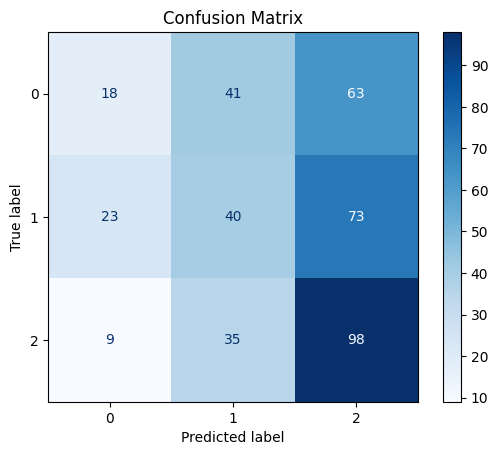


Feature Importance
                Feature  Coefficient  Absolute
4  vehicle_count_trucks     0.055136  0.055136
9     accident_reported     0.051337  0.051337
8              humidity    -0.051330  0.051330
3    vehicle_count_cars    -0.046473  0.046473
1        traffic_volume     0.031317  0.031317
7           temperature    -0.025930  0.025930
0           location_id    -0.024985  0.024985
5   vehicle_count_bikes    -0.024211  0.024211
2     avg_vehicle_speed     0.023234  0.023234
6     weather_condition     0.022861  0.022861


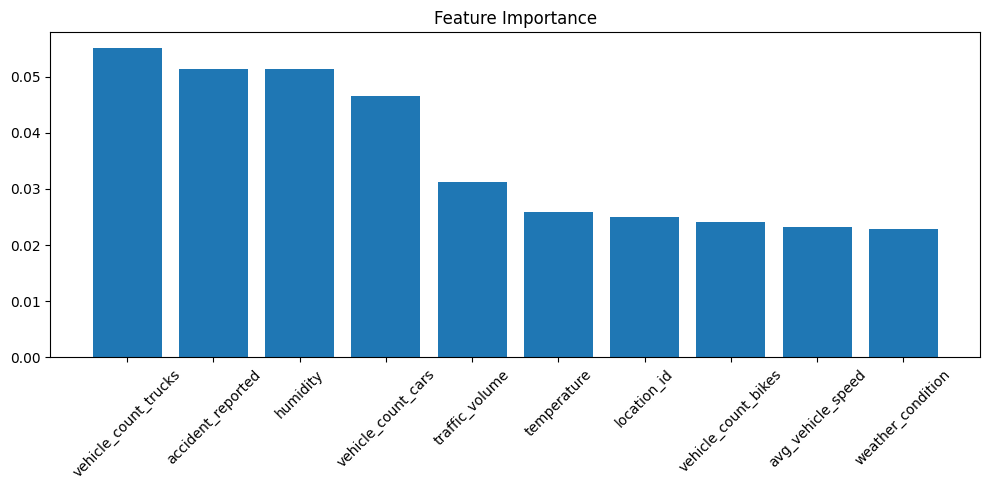


Model Saved Successfully!


In [1]:
# ============================================================
# Smart Traffic Management System
# Logistic Regression + RandomizedSearchCV
# Google Colab
# ============================================================

# Install libraries (if needed)
!pip -q install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from scipy.stats import uniform

# ============================================================
# Upload Dataset
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())

# ============================================================
# Drop Timestamp
# ============================================================

df.drop("timestamp", axis=1, inplace=True)

# ============================================================
# Encode Categorical Columns
# ============================================================

encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        encoder = LabelEncoder()
        df[column] = encoder.fit_transform(df[column])
        encoders[column] = encoder

# ============================================================
# Features and Target
# ============================================================

X = df.drop("signal_status", axis=1)

y = df["signal_status"]

# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# Logistic Regression Model
# ============================================================

model = LogisticRegression(max_iter=1000)

# ============================================================
# Hyperparameter Distribution
# ============================================================

param_dist = {

    "C": uniform(0.01,10),

    "solver":[
        "lbfgs",
        "newton-cg",
        "saga"
    ],

    "penalty":[
        "l2"
    ]
}

# ============================================================
# RandomizedSearchCV
# ============================================================

random_search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

# ============================================================
# Train Model
# ============================================================

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\nBest Parameters")
print(random_search.best_params_)

print("\nBest CV Accuracy")
print(random_search.best_score_)

# ============================================================
# Prediction
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy")

print(f"{accuracy*100:.2f}%")

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": best_model.coef_[0]

})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Absolute"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

# ============================================================
# Save Model
# ============================================================

joblib.dump(best_model, "traffic_logistic_randomsearch.pkl")
joblib.dump(scaler, "traffic_scaler.pkl")

print("\nModel Saved Successfully!")

### Train Logistic Regression Model

Initialize and train a Logistic Regression model on the TF-IDF transformed training data.

In [3]:
# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [4]:
pip install joblib

### Save the Trained Logistic Regression Model

It's good practice to save trained models for future use without retraining. We'll use the `joblib` library for this.

In [10]:
import joblib
from sklearn.linear_model import LogisticRegression # Ensure LogisticRegression is imported

# Re-initialize and train the Logistic Regression model if 'model' is not defined or to ensure it's up-to-date
# This assumes X_train and y_train are available from prior cell executions.

# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model
# Ensure X_train and y_train are defined by executing relevant preceding cells
# (e.g., cell 68qI84AAMTIC for data splitting and feature scaling)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully (or re-trained for saving)!")

# Define the filename for the trained model
model_filename = 'logistic_regression_smart_traffic.pkl'

# Save the trained model to disk
joblib.dump(model, model_filename)

print(f"Trained Logistic Regression model saved as '{model_filename}'")

Logistic Regression model trained successfully (or re-trained for saving)!
Trained Logistic Regression model saved as 'logistic_regression_smart_traffic.pkl'


### Load the Saved Logistic Regression Model

Now, let's load the model back from the saved `.pkl` file to ensure it works correctly and then re-evaluate it.

In [12]:
# Load the saved model
loaded_model = joblib.load(model_filename)

print(f"Logistic Regression model loaded from '{model_filename}'")

# Make predictions using the loaded model
y_pred_loaded = loaded_model.predict(X_test)

# Evaluate the loaded model
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
report_loaded = classification_report(y_test, y_pred_loaded)

print(f"\nAccuracy of loaded model: {accuracy_loaded:.4f}")
print("\nClassification Report of loaded model:")
print(report_loaded)

# Define y_pred for comparison (if 'model' is available from a previous cell)
# This assumes the 'model' variable is still in the kernel from prior training (e.g., cell 7facc5af).
# If not, you might need to re-run the model training cell explicitly before this one.
try:
    y_pred = model.predict(X_test)
except NameError:
    print("Warning: 'model' variable not found. Skipping direct comparison with original model predictions.")
    y_pred = None # Set to None or handle as appropriate if original model predictions are critical

# Verify that predictions are identical
if y_pred is not None and (y_pred == y_pred_loaded).all():
    print("\nVerification successful: Predictions from original and loaded models are identical.")
elif y_pred is not None:
    print("\nVerification failed: Predictions from original and loaded models differ.")
else:
    print("\nVerification could not be performed due to missing original model predictions (y_pred).")

Logistic Regression model loaded from 'logistic_regression_smart_traffic.pkl'

Accuracy of loaded model: 0.3925

Classification Report of loaded model:
              precision    recall  f1-score   support

           0       0.37      0.15      0.21       122
           1       0.34      0.29      0.32       136
           2       0.42      0.70      0.53       142

    accuracy                           0.39       400
   macro avg       0.38      0.38      0.35       400
weighted avg       0.38      0.39      0.36       400


Verification successful: Predictions from original and loaded models are identical.
